<a href="https://colab.research.google.com/github/GabrielaRguezCampos/GabrielaRguezCampos/blob/main/Discount_Tier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Load Datasets

In [ ]:
#  cell for loading dataframes from shared google drive
import pandas as pd

# mount google drive
from google.colab import drive
drive.mount('/content/drive')

# Load each into DataFrames
order_df = pd.read_csv("/content/drive/MyDrive/HEAT x FIU - Temp Folder/shopify_orders.csv", header=None)


# column assignment

order_columns = [
    "SeasonKey", "OrderHeaderKey", "CheckoutHeaderKey", "OrderKey", "OrderID",
    "OrderName", "OrderNumber", "Token", "OrderStatus", "CustomerKey", "CustomerID",
    "CustomerFirstName", "CustomerLastName", "CustomerEmail", "OrderTotalQuantity",
    "OrderSubTotal", "OrderTotalPrice", "CreatedDatetime", "OrderLineItemKey",
    "OrderLineItemID", "LineItemQuantity", "LineItemActualPrice", "LineItemPrice",
    "LineItemDiscountAmount", "LineItemTotalPrice", "ProductKey", "ProductID",
    "ProductTitle", "ProductDescription", "ProductTags", "ProductURL", "VariantSKU",
    "VariantID", "FullVariantTitle", "VariantURL", "OrderContactKey", "CheckoutEmail",
    "BillingCompany", "BillingFirstName", "BillingLastName", "BillingPhone",
    "BillingAddressID", "BillingAddress1", "BillingAddress2", "BillingLatitude",
    "BillingLongitude", "BillingCity", "BillingZipCode", "BillingProvinceCode",
    "BillingProvinceName", "BillingCountryCode", "BillingCountryName",
    "ShippingCompany", "ShippingFirstName", "ShippingLastName", "ShippingPhone",
    "ShippingAddressID", "ShippingAddress1", "ShippingAddress2", "ShippingLatitude",
    "ShippingLongitude", "ShippingCity", "ShippingZipCode", "ShippingProvinceCode",
    "ShippingProvinceName", "ShippingCountryCode", "ShippingCountryName",
    "LastUpdateDateTime", "OrderToken", "OrderShippingPrice", "rownum",
    "MasterEventKey", "dwh_insert_datetime", "dwh_update_datetime",
    "OrderCurrentSubTotal", "OrderCurrentTotalPrice", "OrderCurrentTotalDiscounts",
    "OrderCurrentTotalTax", "UpdatedDateTime", "TaxesAmount", "HCS_Key",
    "LineItemTotalTax", "OrderShippingTotalTax"
]


# Assign the column names
order_df.columns = order_columns



Mounted at /content/drive


<ipython-input-3-7801828>:9: DtypeWarning: Columns (73,78) have mixed types. Specify dtype option on import or set low_memory=False.
  order_df = pd.read_csv("/content/drive/MyDrive/HEAT x FIU - Temp Folder/shopify_orders.csv", header=None)


In [ ]:
# Keep Columns I need

order_cols_to_keep = [
    "OrderID", "CheckoutHeaderKey", "CustomerID", "VariantSKU",
    "OrderTotalPrice", "OrderSubTotal",
    "LineItemDiscountAmount","OrderTotalQuantity","OrderLineItemKey","LineItemQuantity", "CreatedDatetime",
    "LineItemPrice", "LineItemTotalPrice"
]

order_df = order_df[order_cols_to_keep]


In [ ]:
order_df.head(10)

,OrderID,CheckoutHeaderKey,CustomerID,VariantSKU,OrderTotalPrice,OrderSubTotal,LineItemDiscountAmount,OrderTotalQuantity,OrderLineItemKey,LineItemQuantity,CreatedDatetime,LineItemPrice,LineItemTotalPrice
0,597843968043,275567,5095538055,113804,65.99,56.0,0.0,2,496612,1,2018-06-28 08:10:49.000,28.0,28.0
1,597843968043,275567,5095538055,109559,65.99,56.0,0.0,2,496720,1,2018-06-28 08:10:49.000,28.0,28.0
2,570409091115,275590,4894270407,001880,60.87,48.0,0.0,1,496548,1,2018-06-07 10:18:14.000,48.0,48.0
3,590543192107,275531,740085039147,112028,117.53,100.5,0.0,6,496433,1,2018-06-22 13:14:13.000,36.0,36.0
4,590543192107,275531,740085039147,<Unknown>,117.53,100.5,7.5,6,496583,1,2018-06-22 13:14:13.000,15.0,15.0
5,590543192107,275531,740085039147,<Unknown>,117.53,100.5,7.5,6,496644,1,2018-06-22 13:14:13.000,15.0,15.0
6,590543192107,275531,740085039147,112017,117.53,100.5,0.0,6,496727,1,2018-06-22 13:14:13.000,32.0,32.0
7,590543192107,275531,740085039147,111368,117.53,100.5,7.5,6,496764,1,2018-06-22 13:14:13.000,15.0,15.0
8,590543192107,275531,740085039147,000668,117.53,100.5,10.0,6,496871,1,2018-06-22 13:14:13.000,20.0,20.0
9,594294800427,275576,815835217963,111931,65.99,56.0,0.0,2,496666,1,2018-06-25 17:27:22.000,28.0,28.0


# Calculate Discount Rate

Aggregate the Data by OrderID

In [ ]:
aggregated_orders_df = order_df.groupby('OrderID').agg({
    'CustomerID': 'first',
    'OrderTotalPrice': 'first',           # Already total per order
    'OrderSubTotal': 'first',            # Already subtotal per order
    'LineItemDiscountAmount': 'sum',     # Sum of all item-level discounts
    'LineItemTotalPrice': 'sum',         # Total paid price (per item × quantity)
    'CreatedDatetime': 'first',
    'LineItemQuantity': 'sum'            # Total quantity of items in the order
}).reset_index()

# Rename quantity column if needed
aggregated_orders_df.rename(columns={'LineItemQuantity': 'ItemQuantity'}, inplace=True)


In [ ]:
aggregated_orders_df.head(10)

,OrderID,CustomerID,OrderTotalPrice,OrderSubTotal,LineItemDiscountAmount,LineItemTotalPrice,CreatedDatetime,ItemQuantity
0,5797763079,6763490759,93.91,69.00,0.0,69.00,2017-07-09 18:36:25.000,1
1,5967748999,6969876615,126.99,110.00,110.0,220.00,2017-08-15 23:56:22.000,2
2,5968836231,4893980871,123.69,110.00,110.0,220.00,2017-08-16 10:08:45.000,2
3,5973399047,6989959879,140.41,110.00,110.0,220.00,2017-08-17 14:45:35.000,2
4,5976057415,6892267271,142.53,110.00,110.0,220.00,2017-08-18 10:25:56.000,2
5,6040296967,7071059655,33.99,28.00,0.0,28.00,2017-09-06 08:54:51.000,1
6,6042493639,7074151623,83.99,78.00,0.0,78.00,2017-09-06 18:50:29.000,3
7,6046094471,7077910023,27.37,19.98,0.0,19.98,2017-09-07 20:13:13.000,2
8,6050613127,7075406151,82.23,53.49,13.5,66.99,2017-09-09 08:09:53.000,3
9,6056380871,6476806215,35.95,28.00,0.0,28.00,2017-09-11 05:23:11.000,1


# Calculate Discount Rate per Order as %

In [ ]:
aggregated_orders_df['DiscountRate'] = (
    aggregated_orders_df['LineItemDiscountAmount'] /
    (aggregated_orders_df['LineItemDiscountAmount'] + aggregated_orders_df['LineItemTotalPrice']) * 100
).round(2)


In [ ]:
aggregated_orders_df.head(10)

,OrderID,CustomerID,OrderTotalPrice,OrderSubTotal,LineItemDiscountAmount,LineItemTotalPrice,CreatedDatetime,ItemQuantity,DiscountRate
0,5797763079,6763490759,93.91,69.00,0.0,69.00,2017-07-09 18:36:25.000,1,0.00
1,5967748999,6969876615,126.99,110.00,110.0,220.00,2017-08-15 23:56:22.000,2,33.33
2,5968836231,4893980871,123.69,110.00,110.0,220.00,2017-08-16 10:08:45.000,2,33.33
3,5973399047,6989959879,140.41,110.00,110.0,220.00,2017-08-17 14:45:35.000,2,33.33
4,5976057415,6892267271,142.53,110.00,110.0,220.00,2017-08-18 10:25:56.000,2,33.33
5,6040296967,7071059655,33.99,28.00,0.0,28.00,2017-09-06 08:54:51.000,1,0.00
6,6042493639,7074151623,83.99,78.00,0.0,78.00,2017-09-06 18:50:29.000,3,0.00
7,6046094471,7077910023,27.37,19.98,0.0,19.98,2017-09-07 20:13:13.000,2,0.00
8,6050613127,7075406151,82.23,53.49,13.5,66.99,2017-09-09 08:09:53.000,3,16.77
9,6056380871,6476806215,35.95,28.00,0.0,28.00,2017-09-11 05:23:11.000,1,0.00


In [ ]:
aggregated_orders_df.shape

(310090, 9)

In [ ]:
aggregated_orders_df['DiscountRate'].describe()


,DiscountRate
count,310065.000000
mean,4.901265
std,9.969965
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,50.000000


In [ ]:
aggregated_orders_df['DiscountRate'].value_counts(normalize=True).sort_index().head(10)


,proportion
DiscountRate,
0.00,0.761634
0.01,0.000006
0.03,0.000003
0.12,0.000003
0.13,0.000003
0.21,0.000003
0.33,0.000006
0.49,0.000003
0.60,0.000003


# Create Boolean Has_Discount

In [ ]:
aggregated_orders_df['HasDiscount'] = (aggregated_orders_df['LineItemDiscountAmount'] > 0).astype(int)


In [ ]:
aggregated_orders_df.head()

,OrderID,CustomerID,OrderTotalPrice,OrderSubTotal,LineItemDiscountAmount,LineItemTotalPrice,CreatedDatetime,ItemQuantity,DiscountRate,HasDiscount
0,5797763079,6763490759,93.91,69.0,0.0,69.0,2017-07-09 18:36:25.000,1,0.00,0
1,5967748999,6969876615,126.99,110.0,110.0,220.0,2017-08-15 23:56:22.000,2,33.33,1
2,5968836231,4893980871,123.69,110.0,110.0,220.0,2017-08-16 10:08:45.000,2,33.33,1
3,5973399047,6989959879,140.41,110.0,110.0,220.0,2017-08-17 14:45:35.000,2,33.33,1
4,5976057415,6892267271,142.53,110.0,110.0,220.0,2017-08-18 10:25:56.000,2,33.33,1


# Assign Discount Tier

In [ ]:
# Filter only discounted orders
IQR_discounted_df = aggregated_orders_df[aggregated_orders_df['HasDiscount'] == 1]

# Calculate Q1, Q3, and IQR
Q1 = IQR_discounted_df['DiscountRate'].quantile(0.25)
Q3 = IQR_discounted_df['DiscountRate'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds (optional: use for understanding spread or filtering)
lower_bound = max(0, Q1 - 1.5 * IQR)  # clamp to 0, since discount rate can't be negative
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"IQR Range: [{lower_bound:.2f}, {upper_bound:.2f}]")


Q1: 9.09, Q3: 28.57, IQR: 19.48
IQR Range: [0.00, 57.79]


In [ ]:
# Define tier thresholds
low_threshold = Q1            # up to 25% percentile
medium_threshold = Q3         # up to 75% percentile
high_threshold = upper_bound  # above 75% (optional)

def get_discount_tier(rate):
    if pd.isna(rate) or rate == 0:
        return 'No Discount'
    elif rate <= low_threshold:
        return 'Low'
    elif rate <= medium_threshold:
        return 'Medium'
    else:
        return 'High'


In [ ]:
aggregated_orders_df['DiscountTier'] = aggregated_orders_df['DiscountRate'].apply(get_discount_tier)

In [ ]:
tier_summary = aggregated_orders_df['DiscountTier'].value_counts().reset_index()
tier_summary.columns = ['DiscountTier', 'Count']
tier_summary['Percentage'] = (tier_summary['Count'] / tier_summary['Count'].sum() * 100).round(2)

display(tier_summary)


,DiscountTier,Count,Percentage
0,No Discount,236181,76.17
1,Medium,35032,11.30
2,Low,20815,6.71
3,High,18062,5.82


In [ ]:
aggregated_orders_df['DiscountTier'] = aggregated_orders_df['DiscountRate'].apply(get_discount_tier)


In [ ]:
aggregated_orders_df.head()

,OrderID,CustomerID,OrderTotalPrice,OrderSubTotal,LineItemDiscountAmount,LineItemTotalPrice,CreatedDatetime,ItemQuantity,DiscountRate,HasDiscount,DiscountTier
0,5797763079,6763490759,93.91,69.0,0.0,69.0,2017-07-09 18:36:25.000,1,0.00,0,No Discount
1,5967748999,6969876615,126.99,110.0,110.0,220.0,2017-08-15 23:56:22.000,2,33.33,1,High
2,5968836231,4893980871,123.69,110.0,110.0,220.0,2017-08-16 10:08:45.000,2,33.33,1,High
3,5973399047,6989959879,140.41,110.0,110.0,220.0,2017-08-17 14:45:35.000,2,33.33,1,High
4,5976057415,6892267271,142.53,110.0,110.0,220.0,2017-08-18 10:25:56.000,2,33.33,1,High


# Save csv

In [ ]:
aggregated_orders_df.to_csv('aggregated_orders_df.csv', index=False)

In [ ]:
from google.colab import files
files.download('aggregated_orders_df.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
aggregated_orders_df['DiscountRate'].describe()

,DiscountRate
count,310065.000000
mean,4.901265
std,9.969965
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,50.000000


# Check for Outliers

In [ ]:
aggregated_orders_df[aggregated_orders_df['DiscountRate'] > 1].sort_values('DiscountRate', ascending=False).head(10)


,OrderID,CustomerID,OrderTotalPrice,OrderSubTotal,LineItemDiscountAmount,LineItemTotalPrice,CreatedDatetime,ItemQuantity,DiscountRate,DiscountTier
66542,2746803978374,3677357637766,9.99,0.00,125.00,125.00,2020-09-10 11:02:49.000,1,50.00,Medium
72109,2774666117254,3684637114502,10.84,0.00,93.99,93.99,2020-09-22 22:14:26.000,4,50.00,Medium
187973,4849815093382,5525637398662,0.00,0.00,70.00,70.00,2022-12-12 23:48:03.000,1,50.00,Medium
66740,2747741208710,3632221585542,12.99,0.00,120.00,120.00,2020-09-10 21:16:05.000,1,50.00,Medium
68661,2759758217350,4894621063,10.69,0.00,149.00,149.00,2020-09-16 11:50:10.000,2,50.00,Medium
187987,4849931845766,6078323556486,0.00,0.00,140.00,140.00,2022-12-13 01:13:45.000,1,50.00,Medium
227164,5328389275782,1050843021355,0.00,0.00,37.50,37.50,2023-10-04 10:29:48.000,1,50.00,Medium
69246,2763452776582,2991855304838,10.70,0.01,9.99,10.00,2020-09-17 17:19:33.000,1,49.97,Medium
69365,2763777704070,229485576230,10.70,0.01,9.99,10.00,2020-09-17 20:23:19.000,1,49.97,Medium
69196,2763326095494,2999189504134,10.70,0.01,9.99,10.00,2020-09-17 15:46:05.000,1,49.97,Medium


In [ ]:
order_df[order_df['OrderID'] == 5212733472902]


,OrderID,CheckoutHeaderKey,CustomerID,VariantSKU,OrderTotalPrice,OrderSubTotal,LineItemDiscountAmount,OrderTotalQuantity,OrderLineItemKey,LineItemQuantity,CreatedDatetime,LineItemPrice,LineItemTotalPrice
459826,5212733472902,104688,434181537835,127070,562.81,516.0,344.0,86,184462,86,2023-07-23 17:59:14.000,10.0,860.0


In [ ]:
order_df[order_df['OrderID'] == 3821843775622]

,OrderID,CheckoutHeaderKey,CustomerID,VariantSKU,OrderTotalPrice,OrderSubTotal,LineItemDiscountAmount,OrderTotalQuantity,OrderLineItemKey,LineItemQuantity,CreatedDatetime,LineItemPrice,LineItemTotalPrice
96316,3821843775622,66773,461404536875,120020,1750.0,1750.0,1750.0,28,95788,28,2021-06-04 11:02:59.000,125.0,3500.0


### Outlier count

In [ ]:
outlier_count = (aggregated_orders_df['DiscountRate'] > 100).sum()
print("Outlier count:", outlier_count)


Outlier count: 0


In [ ]:
total = len(aggregated_orders_df)
outlier_pct = (outlier_count / total * 100).round(2)
print(f"Outliers: {outlier_count} orders ({outlier_pct}% of all orders)")


Outliers: 597 orders (0.19% of all orders)


### Check sample outlier's history

In [ ]:
order_df[order_df['CustomerID'] == 461404536875]

,OrderID,CheckoutHeaderKey,CustomerID,VariantSKU,OrderTotalPrice,OrderSubTotal,LineItemDiscountAmount,OrderTotalQuantity,OrderLineItemKey,LineItemQuantity,CreatedDatetime,LineItemPrice,LineItemTotalPrice
13872,1978296008838,170309,461404536875,117442,1867.50,1867.5,25.0,10,435287,1,2020-02-09 04:52:53.000,250.0,250.0
13873,1978296008838,170309,461404536875,117449,1867.50,1867.5,50.0,10,435420,2,2020-02-09 04:52:53.000,250.0,500.0
13874,1978296008838,170309,461404536875,119585,1867.50,1867.5,12.5,10,435448,1,2020-02-09 04:52:53.000,125.0,125.0
13875,1978296008838,170309,461404536875,117455,1867.50,1867.5,15.0,10,435474,1,2020-02-09 04:52:53.000,150.0,150.0
13876,1978296008838,170309,461404536875,117443,1867.50,1867.5,75.0,10,435556,3,2020-02-09 04:52:53.000,250.0,750.0
13877,1978296008838,170309,461404536875,117461,1867.50,1867.5,30.0,10,435559,2,2020-02-09 04:52:53.000,150.0,300.0
29807,1897103491206,247099,461404536875,116651,250.00,250.0,0.0,2,451458,2,2019-11-27 00:40:06.000,125.0,250.0
31802,1904535699590,247903,461404536875,112513,231.00,231.0,99.0,3,453279,3,2019-11-30 01:12:53.000,110.0,330.0
73476,1958475923590,170604,461404536875,118013,247.59,237.6,26.4,3,495066,3,2020-01-18 08:25:30.000,88.0,264.0
73775,1959348895878,274489,461404536875,118013,247.59,237.6,26.4,3,495134,3,2020-01-19 08:45:51.000,88.0,264.0


# Check for one regular order

In [ ]:
order_df[order_df['OrderID'] == 590543192107]


,OrderID,CheckoutHeaderKey,CustomerID,VariantSKU,CustomerEmail,OrderTotalPrice,OrderSubTotal,LineItemDiscountAmount,CreatedDatetime,LineItemActualPrice,LineItemPrice,LineItemTotalPrice
3,590543192107,275531,740085039147,112028,adams17@consultant.com,117.53,100.5,0.0,2018-06-22 13:14:13.000,0.0,36.0,36.0
4,590543192107,275531,740085039147,<Unknown>,adams17@consultant.com,117.53,100.5,7.5,2018-06-22 13:14:13.000,0.0,15.0,15.0
5,590543192107,275531,740085039147,<Unknown>,adams17@consultant.com,117.53,100.5,7.5,2018-06-22 13:14:13.000,0.0,15.0,15.0
6,590543192107,275531,740085039147,112017,adams17@consultant.com,117.53,100.5,0.0,2018-06-22 13:14:13.000,0.0,32.0,32.0
7,590543192107,275531,740085039147,111368,adams17@consultant.com,117.53,100.5,7.5,2018-06-22 13:14:13.000,0.0,15.0,15.0
8,590543192107,275531,740085039147,000668,adams17@consultant.com,117.53,100.5,10.0,2018-06-22 13:14:13.000,0.0,20.0,20.0


In [ ]:
subset = order_df[order_df['OrderID'] == 590543192107]

a = subset['LineItemDiscountAmount'].sum()        # should match aggregated LineItemDiscountAmount
b = subset['LineItemPrice'].sum()                 # should match aggregated LineItemPrice
c = subset['OrderTotalPrice'].iloc[0]             # total price (since it's constant across rows)
d = subset['OrderSubTotal'].iloc[0]               # subtotal

print(c)
print(d)
print(a)
print(b)

len(subset)                                   # should match ItemQuantity

117.53
100.5
32.5
133.0


6

In [ ]:
aggregated_orders_df[aggregated_orders_df['OrderID'] == 590543192107]


,OrderID,CustomerID,CustomerEmail,OrderTotalPrice,OrderSubTotal,LineItemDiscountAmount,LineItemPrice,CreatedDatetime,ItemQuantity,DiscountRate,HasDiscount,DiscountTier
950,590543192107,740085039147,adams17@consultant.com,117.53,100.5,32.5,133.0,2018-06-22 13:14:13.000,6,24.44,True,Medium


# Test removing non-discouts

In [ ]:
# Filter Out No-Discount Orders
discounted_df = aggregated_orders_df[aggregated_orders_df['DiscountRate'] > 0].copy()


In [ ]:
print(discounted_df.shape)
print("Minimum discount rate:", discounted_df['DiscountRate'].min())


(73909, 11)
Minimum discount rate: 0.01


In [ ]:
discounted_df['DiscountRate'].describe()


,DiscountRate
count,73909.000000
mean,20.561917
std,9.746452
min,0.010000
25%,9.090000
50%,22.060000
75%,28.570000
max,50.000000


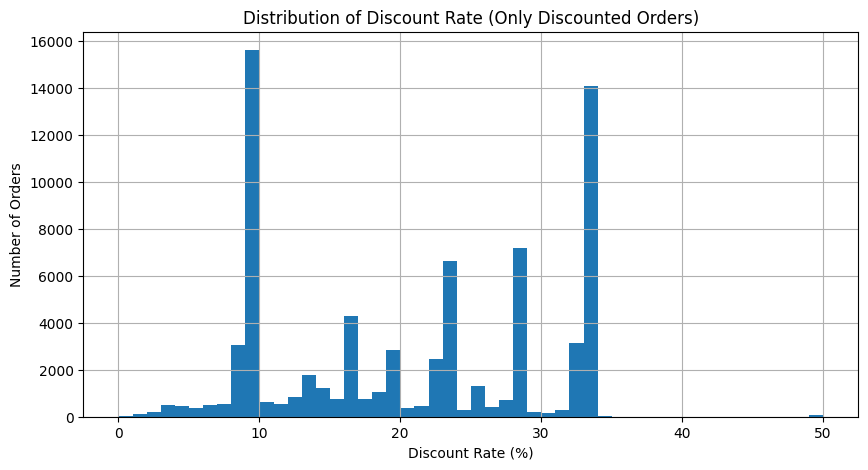

In [ ]:
import matplotlib.pyplot as plt

discounted_df['DiscountRate'].hist(bins=50, figsize=(10, 5))
plt.title("Distribution of Discount Rate (Only Discounted Orders)")
plt.xlabel("Discount Rate (%)")
plt.ylabel("Number of Orders")
plt.grid(True)
plt.show()


# Discount tier from discounted orders analysis

In [ ]:
def get_discount_tier(rate):
    if pd.isna(rate) or rate == 0:
        return 'No Discount'
    elif rate <= 10:
        return 'Low'
    elif rate <= 30:
        return 'Medium'
    else:
        return 'High'

discounted_df['DiscountTier'] = discounted_df['DiscountRate'].apply(get_discount_tier)


NameError: name 'discounted_df' is not defined

In [ ]:
tier_summary = discounted_df['DiscountTier'].value_counts().reset_index()
tier_summary.columns = ['DiscountTier', 'Count']
tier_summary['Percentage'] = (tier_summary['Count'] / tier_summary['Count'].sum() * 100).round(2)

display(tier_summary)


,DiscountTier,Count,Percentage
0,Medium,34748,47.01
1,Low,21350,28.89
2,High,17811,24.10


In [ ]:
discounted_df.head()

,OrderID,CustomerID,OrderTotalPrice,OrderSubTotal,LineItemDiscountAmount,LineItemTotalPrice,CreatedDatetime,ItemQuantity,DiscountRate,HasDiscount,DiscountTier
1,5967748999,6969876615,126.99,110.00,110.0,220.00,2017-08-15 23:56:22.000,2,33.33,1,High
2,5968836231,4893980871,123.69,110.00,110.0,220.00,2017-08-16 10:08:45.000,2,33.33,1,High
3,5973399047,6989959879,140.41,110.00,110.0,220.00,2017-08-17 14:45:35.000,2,33.33,1,High
4,5976057415,6892267271,142.53,110.00,110.0,220.00,2017-08-18 10:25:56.000,2,33.33,1,High
8,6050613127,7075406151,82.23,53.49,13.5,66.99,2017-09-09 08:09:53.000,3,16.77,1,Medium


IQR Analysis for Discount Tier limits

In [ ]:
# Step 1: Filter only discounted orders
IQR_discounted_df = aggregated_orders_df[aggregated_orders_df['HasDiscount'] == 1]

# Step 2: Calculate Q1, Q3, and IQR
Q1 = IQR_discounted_df['DiscountRate'].quantile(0.25)
Q3 = IQR_discounted_df['DiscountRate'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"IQR Range: [{lower_bound:.2f}, {upper_bound:.2f}]")

NameError: name 'aggregated_orders_df' is not defined